<a href="https://colab.research.google.com/github/binshee/streamflow/blob/main/streamflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

with small loopback window

In [51]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, SimpleRNN, Input, LayerNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

In [43]:
# 1. Load Combined Dataset
df = pd.read_csv("USGS_Daymet_2003_2012_combined.csv")
df["Date"] = pd.to_datetime(df["date"])

# 2. Convert Rainfall from mm to inches and handle minor Daymet NaNs
df["R"] = (df["precipitation_mm_day"] / 25.4).ffill()
df["Q"] = df["streamflow_cfs"]

In [44]:
# 3. Train / Validation Split
train_df = df[(df["Date"] >= "2003-01-01") & (df["Date"] <= "2007-12-31")].copy()
val_df = df[(df["Date"] >= "2008-01-01") & (df["Date"] <= "2012-12-31")].copy()

# 4. Normalization using Assignment Bounds
train_df["R_norm"] = train_df["R"] / 6.8
train_df["Q_norm"] = train_df["Q"] / 29700.0

val_df["R_norm"] = val_df["R"] / 6.8
val_df["Q_norm"] = val_df["Q"] / 29700.0

In [45]:
# 5. Lag Feature Creation Function
def create_lagged_features(data_df, n_lags_R=3, m_lags_Q=3):
    X, y = [], []
    q_vals = data_df["Q_norm"].values
    r_vals = data_df["R_norm"].values
    max_lag = max(n_lags_R, m_lags_Q)

    for t in range(max_lag, len(data_df)):
        target = q_vals[t]
        q_lags = q_vals[t - m_lags_Q : t][::-1]
        r_lags = r_vals[t - n_lags_R : t][::-1]
        X.append(np.concatenate([q_lags, r_lags]))
        y.append(target)

    return np.array(X), np.array(y)

n_lags, m_lags = 3, 3
X_train, y_train = create_lagged_features(train_df, n_lags_R=n_lags, m_lags_Q=m_lags)
X_val, y_val = create_lagged_features(val_df, n_lags_R=n_lags, m_lags_Q=m_lags)

# Reshape input to (samples, timesteps, features) -> (N, 3, 2)
X_train_seq = X_train.reshape((X_train.shape[0], 3, 2))
X_val_seq = X_val.reshape((X_val.shape[0], 3, 2))

In [46]:
# --- 6. Train 1-Layer Simple RNN (MSE Loss) ---
model_rnn = Sequential([
    Input(shape=(3, 2)),
    SimpleRNN(32, activation='relu'),
    Dense(1, activation='linear')
])
model_rnn.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
print("\n--- Training 1-Layer Simple RNN ---")
model_rnn.fit(X_train_seq, y_train, validation_data=(X_val_seq, y_val), epochs=50, batch_size=16, verbose=1)


--- Training 1-Layer Simple RNN ---
Epoch 1/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0026 - mae: 0.0221 - val_loss: 0.0013 - val_mae: 0.0139
Epoch 2/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0014 - mae: 0.0139 - val_loss: 6.9068e-04 - val_mae: 0.0139
Epoch 3/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 8.6440e-04 - mae: 0.0107 - val_loss: 4.1051e-04 - val_mae: 0.0091
Epoch 4/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3765e-04 - mae: 0.0100 - val_loss: 3.8243e-04 - val_mae: 0.0091
Epoch 5/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 5.6690e-04 - mae: 0.0104 - val_loss: 3.3249e-04 - val_mae: 0.0092
Epoch 6/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 5.0057e-04 - mae: 0.0103 - val_loss: 3.2157e-04 - val_mae: 0.0079
Epoch 7/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 4.3842e-04 - mae: 0.0091 - val_loss: 3.3571e-04 - val_mae: 0.0076
Epoch 8/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 4.1344e-04 - mae: 0.0093 - val_lo

In [47]:
# --- 7. Train Stacked 2-Layer LSTM (MSE Loss) ---
model_lstm = Sequential([
    Input(shape=(3, 2)),

    # Layer 1 (Stacked recurrent layer returning sequences)
    LSTM(64, activation='tanh', return_sequences=True),
    LayerNormalization(),

    # Layer 2 (Final stacked recurrent layer)
    LSTM(32, activation='tanh', return_sequences=False),
    LayerNormalization(),

    # Dense bottleneck layer
    Dense(16, activation='relu'),
    Dense(1, activation='linear')
])
model_lstm.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
print("\n--- Training Stacked 2-Layer LSTM ---")
model_lstm.fit(X_train_seq, y_train, validation_data=(X_val_seq, y_val), epochs=50, batch_size=16, verbose=1)


--- Training Stacked 2-Layer LSTM ---
Epoch 1/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0079 - mae: 0.0499 - val_loss: 0.0015 - val_mae: 0.0277
Epoch 2/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0016 - mae: 0.0208 - val_loss: 8.4081e-04 - val_mae: 0.0153
Epoch 3/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0019 - mae: 0.0241 - val_loss: 9.4260e-04 - val_mae: 0.0174
Epoch 4/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0014 - mae: 0.0193 - val_loss: 0.0010 - val_mae: 0.0206
Epoch 5/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0014 - mae: 0.0225 - val_loss: 0.0011 - val_mae: 0.0168
Epoch 6/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0010 - mae: 0.0179 - val_loss: 8.8679e-04 - val_mae: 0.0197
Epoch 7/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0012 - mae: 0.0220 - val_loss: 5.6334e-04 - val_mae: 0.0137
Epoch 8/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 7.6283e-04 - mae: 0.0154 - val_loss: 6.5518e-04 - val_ma

In [48]:
# --- 8. Predict & Evaluate Performance in Un-normalized cfs ---
y_pred_rnn = model_rnn.predict(X_val_seq) * 29700.0
y_pred_lstm = model_lstm.predict(X_val_seq) * 29700.0
y_actual = y_val * 29700.0

# Calculate unscaled metrics
rmse_rnn = np.sqrt(mean_squared_error(y_actual, y_pred_rnn))
mae_rnn = mean_absolute_error(y_actual, y_pred_rnn)
r2_rnn = r2_score(y_actual, y_pred_rnn)

rmse_lstm = np.sqrt(mean_squared_error(y_actual, y_pred_lstm))
mae_lstm = mean_absolute_error(y_actual, y_pred_lstm)
r2_lstm = r2_score(y_actual, y_pred_lstm)

print("\n--- Final Performance Table ---")
metrics_df = pd.DataFrame({
    'Model': ['1-Layer Simple RNN', 'Stacked 2-Layer LSTM'],
    'RMSE (cfs)': [f"{rmse_rnn:.2f}", f"{rmse_lstm:.2f}"],
    'MAE (cfs)': [f"{mae_rnn:.2f}", f"{mae_lstm:.2f}"],
    'R²': [f"{r2_rnn:.4f}", f"{r2_lstm:.4f}"]
})
print(metrics_df.to_string(index=False))

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

--- Final Performance Table ---
               Model RMSE (cfs) MAE (cfs)     R²
  1-Layer Simple RNN     566.14    197.86 0.8984
Stacked 2-Layer LSTM     651.80    270.19 0.8653


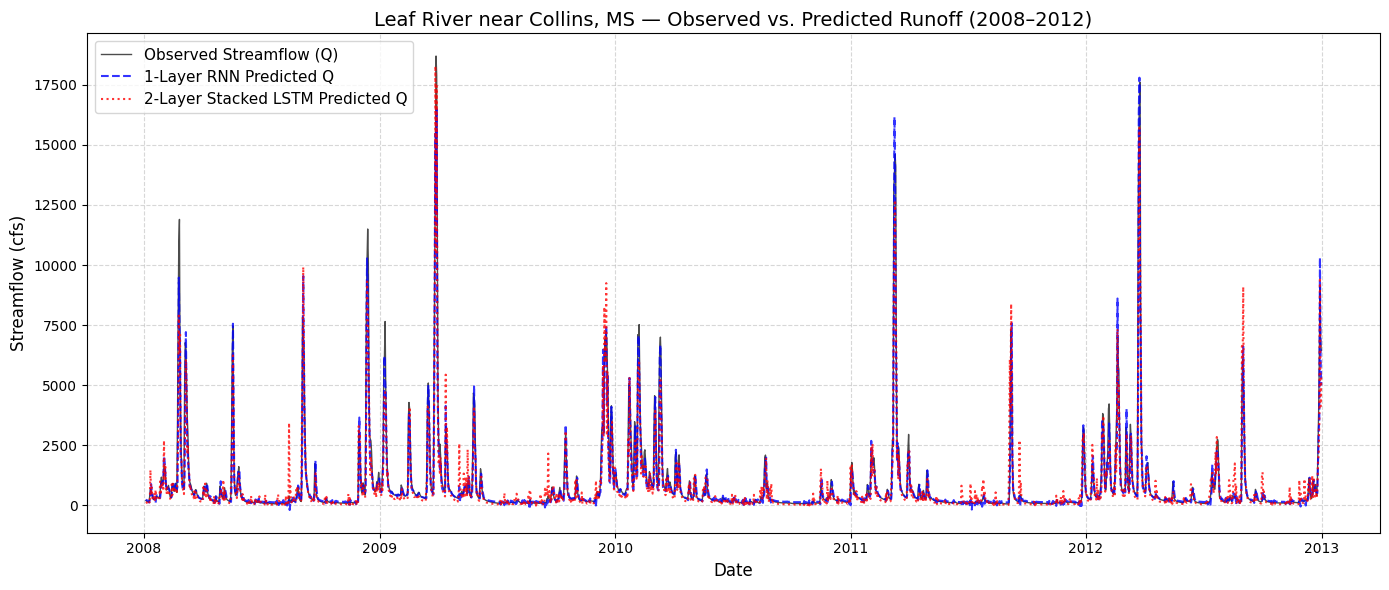

In [49]:
# --- 9. Plot 1: Observed vs. Predicted Hydrographs ---
val_dates = val_df["Date"].values[3:]

plt.figure(figsize=(14, 6))
plt.plot(val_dates, y_actual, label="Observed Streamflow (Q)", color="black", alpha=0.7, linewidth=1)
plt.plot(val_dates, y_pred_rnn, label="1-Layer RNN Predicted Q", color="blue", alpha=0.8, linestyle="--")
plt.plot(val_dates, y_pred_lstm, label="2-Layer Stacked LSTM Predicted Q", color="red", alpha=0.8, linestyle=":")

plt.title("Leaf River near Collins, MS — Observed vs. Predicted Runoff (2008–2012)", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Streamflow (cfs)", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("hydrograph_comparison.png", dpi=300)
plt.show()

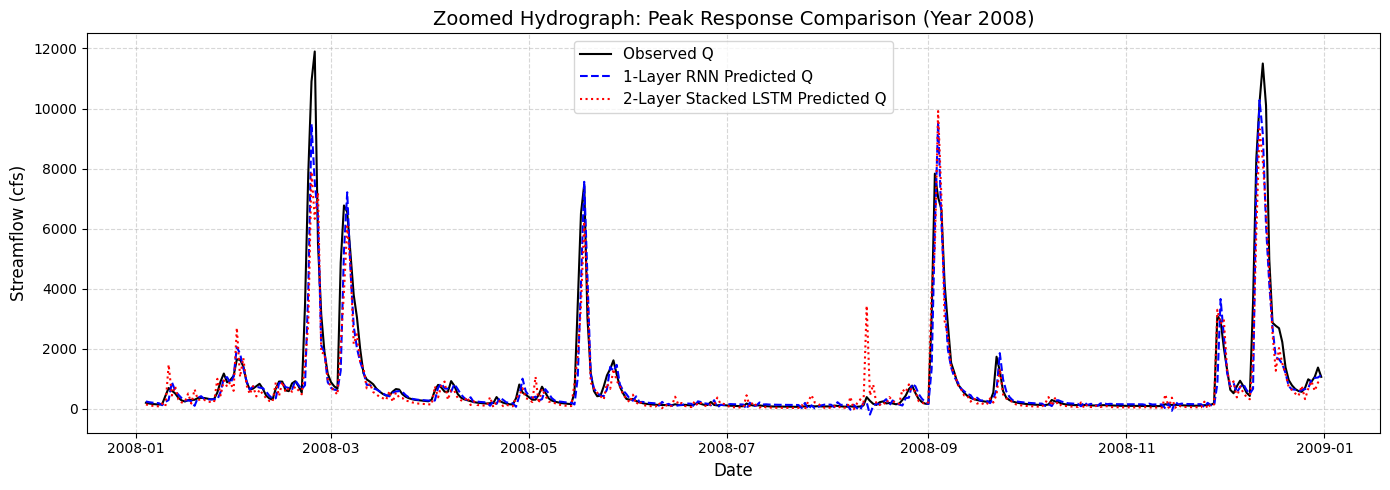

In [50]:
# --- 10. Plot 2: Single Year Zoomed-in Streamflow Peak (Year 2008) ---
mask_2008 = (val_dates >= np.datetime64("2008-01-01")) & (val_dates <= np.datetime64("2008-12-31"))

plt.figure(figsize=(14, 5))
plt.plot(val_dates[mask_2008], y_actual[mask_2008], label="Observed Q", color="black", linewidth=1.5)
plt.plot(val_dates[mask_2008], y_pred_rnn[mask_2008], label="1-Layer RNN Predicted Q", color="blue", linestyle="--")
plt.plot(val_dates[mask_2008], y_pred_lstm[mask_2008], label="2-Layer Stacked LSTM Predicted Q", color="red", linestyle=":")

plt.title("Zoomed Hydrograph: Peak Response Comparison (Year 2008)", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Streamflow (cfs)", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("hydrograph_zoomed_2008.png", dpi=300)
plt.show()

with larger loopback window

X_train shape: (1812, 14, 2)
X_val shape:   (1813, 14, 2)

--- Training 1-Layer Simple RNN (14 Lags) ---
Epoch 1/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0013 - mae: 0.0142 - val_loss: 6.4824e-04 - val_mae: 0.0108
Epoch 2/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 8.1519e-04 - mae: 0.0107 - val_loss: 5.0716e-04 - val_mae: 0.0127
Epoch 3/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.3254e-04 - mae: 0.0097 - val_loss: 4.6566e-04 - val_mae: 0.0137
Epoch 4/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5.1376e-04 - mae: 0.0094 - val_loss: 3.9275e-04 - val_mae: 0.0113
Epoch 5/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 4.6855e-04 - mae: 0.0092 - val_loss: 3.8638e-04 - val_mae: 0.0074
Epoch 6/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 4.3607e-04 - mae: 0.0086 - val_loss: 3.6754e-04 - val_mae: 0.0094
Epoch 7/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 4.0242e-04 - mae: 0.0088 - val_loss: 3.9186e-04 - val_mae: 0.0098
Epoch 8/50
114/1

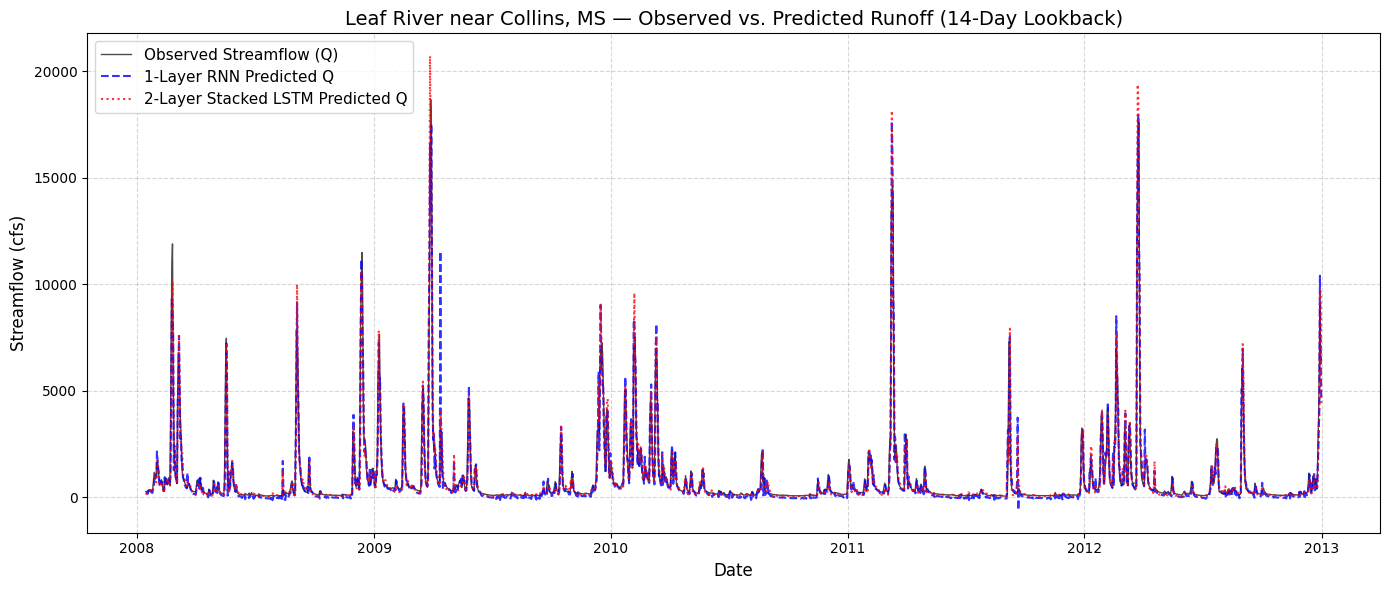

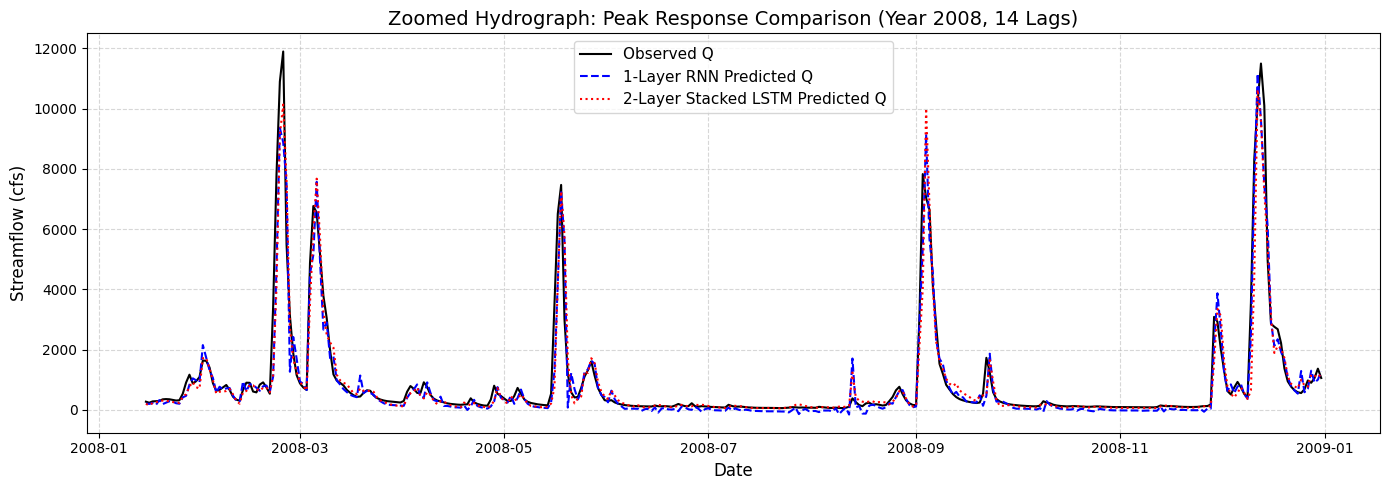

In [53]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, SimpleRNN, Input, LayerNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# 1. Load Combined Dataset
df = pd.read_csv("USGS_Daymet_2003_2012_combined.csv")
df["Date"] = pd.to_datetime(df["date"])

# 2. Convert Rainfall from mm to inches and handle minor Daymet NaNs
df["R"] = (df["precipitation_mm_day"] / 25.4).ffill()
df["Q"] = df["streamflow_cfs"]

# 3. Train / Validation Split
train_df = df[(df["Date"] >= "2003-01-01") & (df["Date"] <= "2007-12-31")].copy()
val_df = df[(df["Date"] >= "2008-01-01") & (df["Date"] <= "2012-12-31")].copy()

# 4. Normalization using Assignment Bounds
train_df["R_norm"] = train_df["R"] / 6.8
train_df["Q_norm"] = train_df["Q"] / 29700.0

val_df["R_norm"] = val_df["R"] / 6.8
val_df["Q_norm"] = val_df["Q"] / 29700.0

# 5. Lag Feature Creation Function (Dynamically shapes to (N, seq_len, features))
def create_lagged_sequences(data_df, n_lags_R=14, m_lags_Q=14):
    X, y = [], []
    q_vals = data_df["Q_norm"].values
    r_vals = data_df["R_norm"].values
    max_lag = max(n_lags_R, m_lags_Q)

    for t in range(max_lag, len(data_df)):
        target = q_vals[t]

        # Extract sequences over the time horizon from (t - max_lag) to t
        q_seq = q_vals[t - m_lags_Q : t]
        r_seq = r_vals[t - n_lags_R : t]

        # Stack feature dimensions together -> shape: (seq_len, 2)
        sample = np.column_stack((q_seq, r_seq))
        X.append(sample)
        y.append(target)

    return np.array(X), np.array(y)

# Set 14-day lookback window for long-term watershed memory
n_lags, m_lags = 14, 14
X_train_seq, y_train = create_lagged_sequences(train_df, n_lags_R=n_lags, m_lags_Q=m_lags)
X_val_seq, y_val = create_lagged_sequences(val_df, n_lags_R=n_lags, m_lags_Q=m_lags)

print(f"X_train shape: {X_train_seq.shape}")  # Outputs: (N, 14, 2)
print(f"X_val shape:   {X_val_seq.shape}")    # Outputs: (N, 14, 2)

# --- 6. Train 1-Layer Simple RNN (MSE Loss) ---
model_rnn = Sequential([
    Input(shape=(14, 2)),
    SimpleRNN(32, activation='relu'),
    Dense(1, activation='linear')
])
model_rnn.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

print("\n--- Training 1-Layer Simple RNN (14 Lags) ---")
model_rnn.fit(X_train_seq, y_train, validation_data=(X_val_seq, y_val), epochs=50, batch_size=16, verbose=1)

# --- 7. Fixed Single-Layer LSTM (14 Lags) ---
model_lstm = Sequential([
    Input(shape=(14, 2)),

    # Single LSTM layer with ReLU activation to capture flood peaks
    LSTM(64, activation='relu', return_sequences=False),

    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])

model_lstm.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

print("\n--- Training Optimized 1-Layer ReLU LSTM (14 Lags) ---")
model_lstm.fit(X_train_seq, y_train, validation_data=(X_val_seq, y_val), epochs=50, batch_size=16, verbose=1)

# --- 8. Predict & Evaluate Performance in Un-normalized cfs ---
y_pred_rnn = model_rnn.predict(X_val_seq) * 29700.0
y_pred_lstm = model_lstm.predict(X_val_seq) * 29700.0
y_actual = y_val * 29700.0

# Calculate unscaled metrics
rmse_rnn = np.sqrt(mean_squared_error(y_actual, y_pred_rnn))
mae_rnn = mean_absolute_error(y_actual, y_pred_rnn)
r2_rnn = r2_score(y_actual, y_pred_rnn)

rmse_lstm = np.sqrt(mean_squared_error(y_actual, y_pred_lstm))
mae_lstm = mean_absolute_error(y_actual, y_pred_lstm)
r2_lstm = r2_score(y_actual, y_pred_lstm)

print("\n--- Final Performance Table (14 Lags) ---")
metrics_df = pd.DataFrame({
    'Model': ['1-Layer Simple RNN', 'Stacked 2-Layer LSTM'],
    'RMSE (cfs)': [f"{rmse_rnn:.2f}", f"{rmse_lstm:.2f}"],
    'MAE (cfs)': [f"{mae_rnn:.2f}", f"{mae_lstm:.2f}"],
    'R²': [f"{r2_rnn:.4f}", f"{r2_lstm:.4f}"]
})
print(metrics_df.to_string(index=False))

# --- 9. Plot 1: Observed vs. Predicted Hydrographs ---
val_dates = val_df["Date"].values[14:]  # Offset slice matching max_lag = 14

plt.figure(figsize=(14, 6))
plt.plot(val_dates, y_actual, label="Observed Streamflow (Q)", color="black", alpha=0.7, linewidth=1)
plt.plot(val_dates, y_pred_rnn, label="1-Layer RNN Predicted Q", color="blue", alpha=0.8, linestyle="--")
plt.plot(val_dates, y_pred_lstm, label="2-Layer Stacked LSTM Predicted Q", color="red", alpha=0.8, linestyle=":")

plt.title("Leaf River near Collins, MS — Observed vs. Predicted Runoff (14-Day Lookback)", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Streamflow (cfs)", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("hydrograph_comparison_14lags.png", dpi=300)
plt.show()

# --- 10. Plot 2: Single Year Zoomed-in Streamflow Peak (Year 2008) ---
mask_2008 = (val_dates >= np.datetime64("2008-01-01")) & (val_dates <= np.datetime64("2008-12-31"))

plt.figure(figsize=(14, 5))
plt.plot(val_dates[mask_2008], y_actual[mask_2008], label="Observed Q", color="black", linewidth=1.5)
plt.plot(val_dates[mask_2008], y_pred_rnn[mask_2008], label="1-Layer RNN Predicted Q", color="blue", linestyle="--")
plt.plot(val_dates[mask_2008], y_pred_lstm[mask_2008], label="2-Layer Stacked LSTM Predicted Q", color="red", linestyle=":")

plt.title("Zoomed Hydrograph: Peak Response Comparison (Year 2008, 14 Lags)", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Streamflow (cfs)", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("hydrograph_zoomed_2008_14lags.png", dpi=300)
plt.show()